In [1]:
import numpy as np
import matplotlib.pyplot as plt
import os
 
# ============================================================
# %% Cell 0: Data loader
# ============================================================
def load_2d(fname):
    """Load a 2D MHD output file. Returns dict with x, y, and all variables."""
    with open(fname) as f:
        header = f.readline().split()
    nx, ny = int(header[0]), int(header[1])
    gama = float(header[2])
    data = np.loadtxt(fname, skiprows=1)
    d = {}
    d['nx'], d['ny'], d['gama'] = nx, ny, gama
    d['x']   = data[:, 0].reshape(ny, nx)
    d['y']   = data[:, 1].reshape(ny, nx)
    d['rho'] = data[:, 2].reshape(ny, nx)
    d['vx']  = data[:, 3].reshape(ny, nx)
    d['vy']  = data[:, 4].reshape(ny, nx)
    d['vz']  = data[:, 5].reshape(ny, nx)
    d['p']   = data[:, 6].reshape(ny, nx)
    d['Bx']  = data[:, 7].reshape(ny, nx)
    d['By']  = data[:, 8].reshape(ny, nx)
    d['Bz']  = data[:, 9].reshape(ny, nx)
    d['psi'] = data[:, 10].reshape(ny, nx)
    d['e']   = data[:, 11].reshape(ny, nx)
    d['divB'] = data[:, 12].reshape(ny, nx)
    return d
 

In [2]:
# ============================================================
# %% Cell 1: 2D colormaps (surface plots, like Toro Figs 17.2/17.3)
# ============================================================
def plot_2d_colormaps(d, title=""):
    """Plot 2D colormaps of density, pressure, specific internal energy."""
    fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))
    fig.suptitle(title, fontsize=14, fontweight='bold')
 
    for ax, key, label in zip(axes,
                               ['rho', 'p', 'e'],
                               [r'$\rho$', r'$p$', r'$e$']):
        im = ax.pcolormesh(d['x'], d['y'], d[key], shading='auto', cmap='viridis')
        ax.set_xlabel('x'); ax.set_ylabel('y')
        ax.set_title(label, fontsize=14)
        ax.set_aspect('equal')
        plt.colorbar(im, ax=ax, shrink=0.8)
 
    plt.tight_layout()
    plt.show()
    plt.close(fig)

In [10]:
# ============================================================
# %% Cell 2: Radial scatter plots 
# ============================================================
def plot_brio_wu(d, axis='x', title=""):
    """1D line plot for Brio-Wu tests: extract the mid-slice along the shock axis."""
    if axis == 'x':
        # Take the row closest to y-midpoint
        y_vals = d['y'][:, 0] if d['y'].ndim == 2 else d['y']
        mid = np.argmin(np.abs(y_vals - 0.5 * (y_vals[0] + y_vals[-1])))
        r       = d['x'][mid, :] if d['x'].ndim == 2 else d['x']
        rho_1d  = d['rho'][mid, :]
        v_1d    = d['vx'][mid, :]
        p_1d    = d['p'][mid, :]
        e_1d    = d['e'][mid, :]
        xlabel  = 'x'
        vlabel  = r'$v_x$'
    else:  # axis == 'y'
        x_vals = d['x'][0, :] if d['x'].ndim == 2 else d['x']
        mid = np.argmin(np.abs(x_vals - 0.5 * (x_vals[0] + x_vals[-1])))
        r       = d['y'][:, mid] if d['y'].ndim == 2 else d['y']
        rho_1d  = d['rho'][:, mid]
        v_1d    = d['vy'][:, mid]
        p_1d    = d['p'][:, mid]
        e_1d    = d['e'][:, mid]
        xlabel  = 'y'
        vlabel  = r'$v_y$'

    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold')

    data_list = [
        (rho_1d, r'$\rho$', 'Density'),
        (v_1d,   vlabel,    f'Velocity ({axis}-dir)'),
        (p_1d,   r'$p$',    'Pressure'),
        (e_1d,   r'$e$',    'Specific internal energy'),
    ]
    for ax, (vals, ylabel, ttl) in zip(axes.flatten(), data_list):
        ax.plot(r, vals, lw=1.0, color='steelblue')
        ax.set_xlabel(xlabel)
        ax.set_ylabel(ylabel)
        ax.set_title(ttl)
        ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    plt.close(fig)

def plot_radial_scatter(d, xc=0.5, yc=0.5, title=""):
    """Scatter plot of variables vs radius from (xc, yc)."""
    x, y = d['x'].flatten(), d['y'].flatten()
    r = np.sqrt((x - xc)**2 + (y - yc)**2)
 
    # Radial velocity
    dist = np.maximum(r, 1e-10)
    vr = ((d['vx'].flatten() * (x - xc) + d['vy'].flatten() * (y - yc)) / dist)
 
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
 
    data_list = [
        (d['rho'].flatten(), r'$\rho$',  'Density'),
        (vr,                 r'$v_r$',   'Radial velocity'),
        (d['p'].flatten(),   r'$p$',     'Pressure'),
        (d['e'].flatten(),   r'$e$',     'Specific internal energy'),
    ]
    for ax, (vals, ylabel, ttl) in zip(axes.flatten(), data_list):
        ax.scatter(r, vals, s=0.1, alpha=0.5)
        ax.set_xlabel('r'); ax.set_ylabel(ylabel)
        ax.set_title(ttl)
        ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()
    plt.close(fig)
 
# ============================================================
# %% Cell 3: Multi-resolution comparison (scatter overlay)
# ============================================================
def plot_convergence(files, xc=0.5, yc=0.5, title="Convergence"):
    """Overlay radial scatter for multiple resolutions."""
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
    colors = ['C0', 'C1', 'C2', 'C3']
 
    for idx, fname in enumerate(files):
        d = load_2d(fname)
        x, y = d['x'].flatten(), d['y'].flatten()
        r = np.sqrt((x - xc)**2 + (y - yc)**2)
        dist = np.maximum(r, 1e-10)
        vr = (d['vx'].flatten()*(x-xc) + d['vy'].flatten()*(y-yc)) / dist
        label = f"{d['nx']}x{d['ny']}"
        c = colors[idx % len(colors)]
        s = 0.3
 
        axes[0,0].scatter(r, d['rho'].flatten(), s=s, alpha=0.4, c=c, label=label)
        axes[0,1].scatter(r, vr,                 s=s, alpha=0.4, c=c, label=label)
        axes[1,0].scatter(r, d['p'].flatten(),   s=s, alpha=0.4, c=c, label=label)
        axes[1,1].scatter(r, d['e'].flatten(),   s=s, alpha=0.4, c=c, label=label)
 
    labels = [r'$\rho$', r'$v_r$', r'$p$', r'$e$']
    titles = ['Density', 'Radial velocity', 'Pressure', 'Specific internal energy']
    for ax, yl, ttl in zip(axes.flatten(), labels, titles):
        ax.set_xlabel('r'); ax.set_ylabel(yl); ax.set_title(ttl)
        ax.legend(markerscale=10); ax.grid(True, alpha=0.3)
 
    plt.tight_layout()
    plt.show()
    plt.close(fig)
 
 
# ============================================================
# %% Cell 4: 1D cut along an axis (for 2D Brio-Wu tests)
# ============================================================
def plot_1d_cut(d, axis='x', cut_pos=None, title=""):
    """Extract a 1D cut along x or y at the given position."""
    if axis == 'x':
        if cut_pos is None:
            jmid = d['ny'] // 2
        else:
            jmid = np.argmin(np.abs(d['y'][:, 0] - cut_pos))
        coord = d['x'][jmid, :]
        rho = d['rho'][jmid, :]
        vn  = d['vx'][jmid, :]
        vt  = d['vy'][jmid, :]
        p   = d['p'][jmid, :]
        Bn  = d['By'][jmid, :]
        xlabel = 'x'
    else:  # y-cut
        if cut_pos is None:
            imid = d['nx'] // 2
        else:
            imid = np.argmin(np.abs(d['x'][0, :] - cut_pos))
        coord = d['y'][:, imid]
        rho = d['rho'][:, imid]
        vn  = d['vy'][:, imid]
        vt  = d['vx'][:, imid]
        p   = d['p'][:, imid]
        Bn  = d['Bx'][:, imid]
        xlabel = 'y'
 
    fig, axes = plt.subplots(2, 3, figsize=(15, 8))
    fig.suptitle(title, fontsize=14, fontweight='bold')
 
    plots = [
        (rho, r'$\rho$'), (vn, r'$v_{normal}$'), (vt, r'$v_{tangent}$'),
        (p, r'$p$'), (Bn, r'$B_{tangent}$'),
    ]
    for ax, (data, label) in zip(axes.flatten(), plots):
        ax.plot(coord, data, linewidth=0.6)
        ax.set_xlabel(xlabel); ax.set_ylabel(label); ax.set_title(label)
        ax.grid(True, alpha=0.3)
    axes[1, 2].set_visible(False)
 
    plt.tight_layout()
    plt.show()
    plt.close(fig)
 
 
# ============================================================
# %% Cell 5: 2D colormap for MHD tests (rho, p, |B|, Mach)
# ============================================================
def plot_2d_mhd(d, title=""):
    """Plot 2D colormaps for MHD variables."""
    Bmag = np.sqrt(d['Bx']**2 + d['By']**2 + d['Bz']**2)
    vmag = np.sqrt(d['vx']**2 + d['vy']**2 + d['vz']**2)
 
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    fig.suptitle(title, fontsize=14, fontweight='bold')
 
    for ax, data, label in zip(axes.flatten(),
                                [d['rho'], d['p'], Bmag, vmag],
                                [r'$\rho$', r'$p$', r'$|B|$', r'$|v|$']):
        im = ax.pcolormesh(d['x'], d['y'], data, shading='auto', cmap='viridis')
        ax.set_aspect('equal')
        ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_title(label)
        plt.colorbar(im, ax=ax, shrink=0.8)
 
    plt.tight_layout()
    plt.show()
    plt.close(fig)

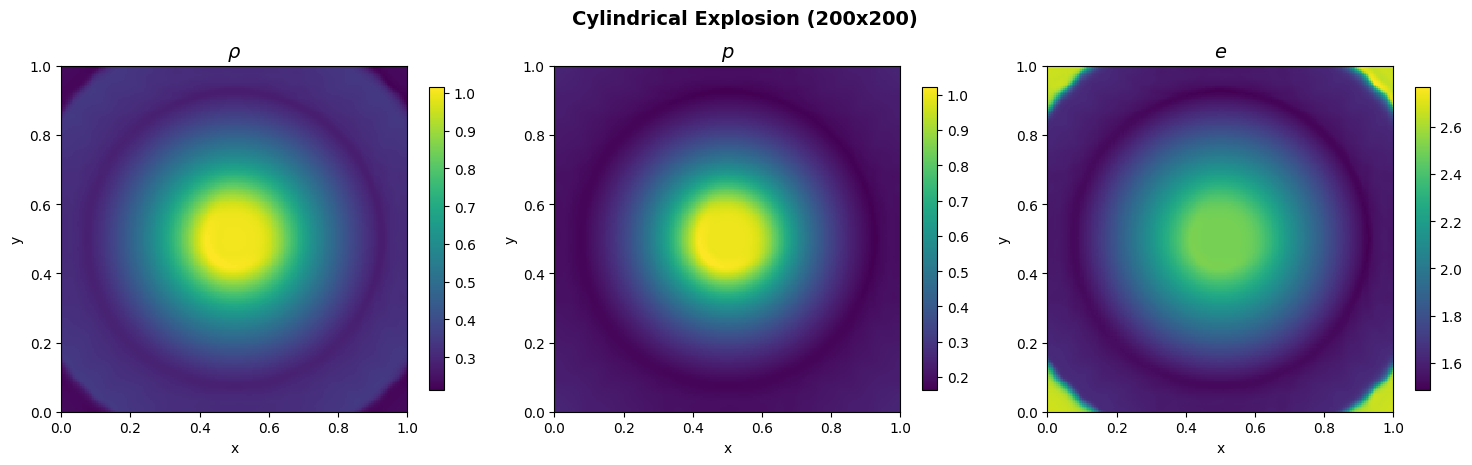

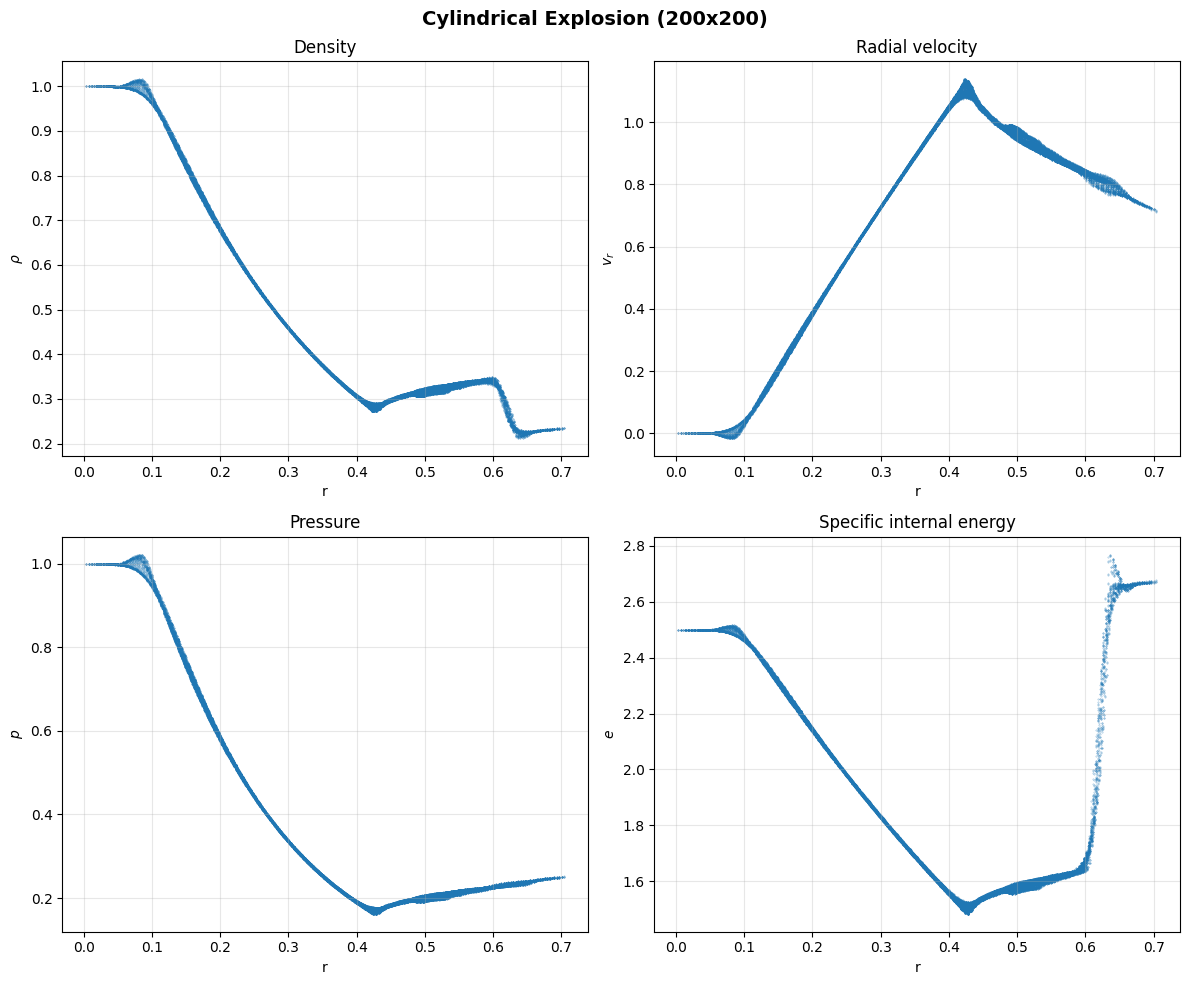

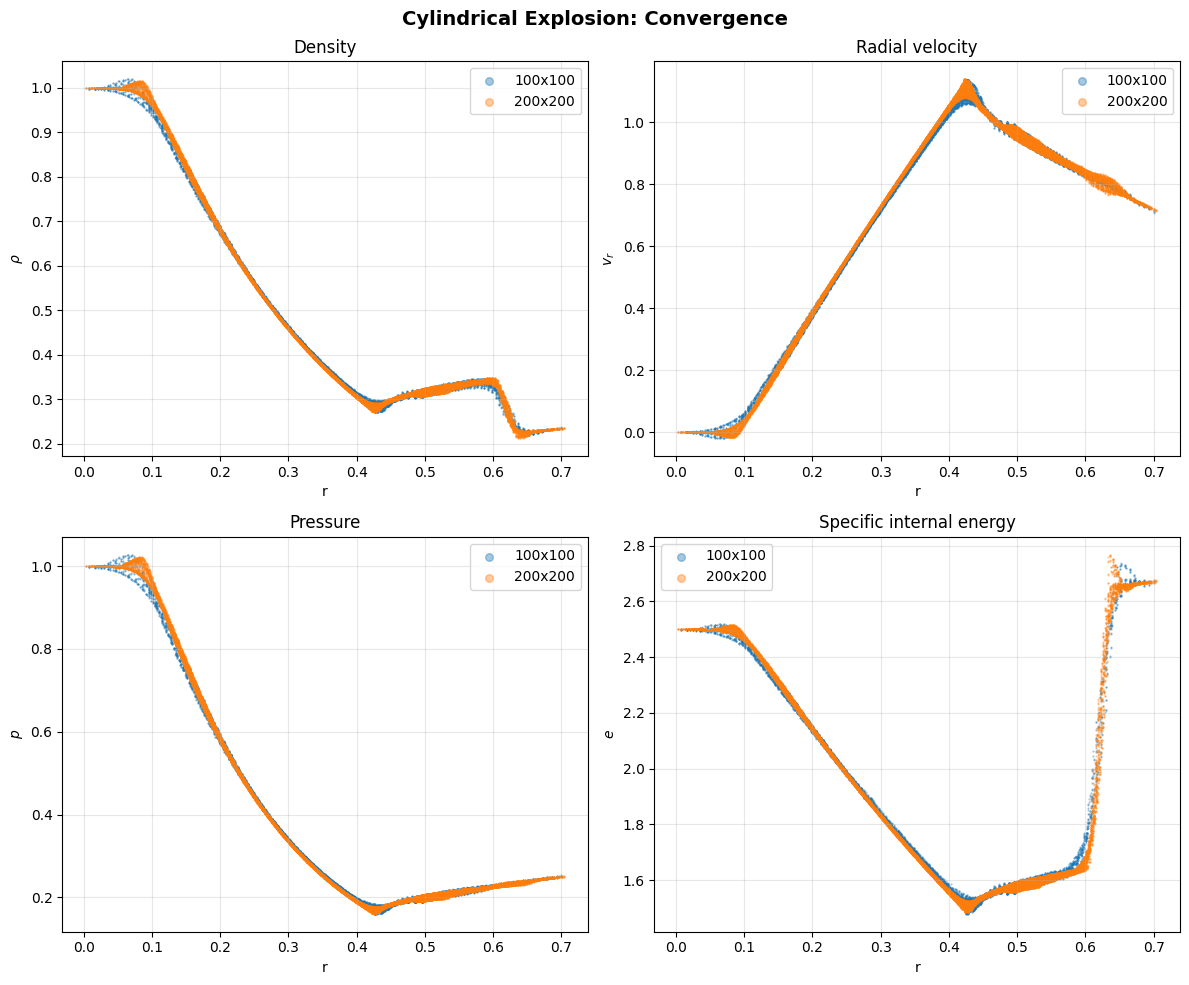

In [11]:
# ============================================================
# %% Cell 6: Run this for the cylindrical explosion test
# ============================================================
# Single resolution
d = load_2d("test0_200x200_hlld_glm.dat")
plot_2d_colormaps(d, "Cylindrical Explosion (200x200)")
plot_radial_scatter(d, title="Cylindrical Explosion (200x200)")
 
# ============================================================
# %% Cell 7: Multi-resolution convergence for cylindrical explosion
# ============================================================
files = ["test0_100x100_hlld_glm.dat", "test0_200x200_hlld_glm.dat"]
# Uncomment after running: ./mhd2d 0 400 400
# files.append("test0_400x400.dat")
files = [f for f in files if os.path.exists(f)]
if files:
    plot_convergence(files, title="Cylindrical Explosion: Convergence")

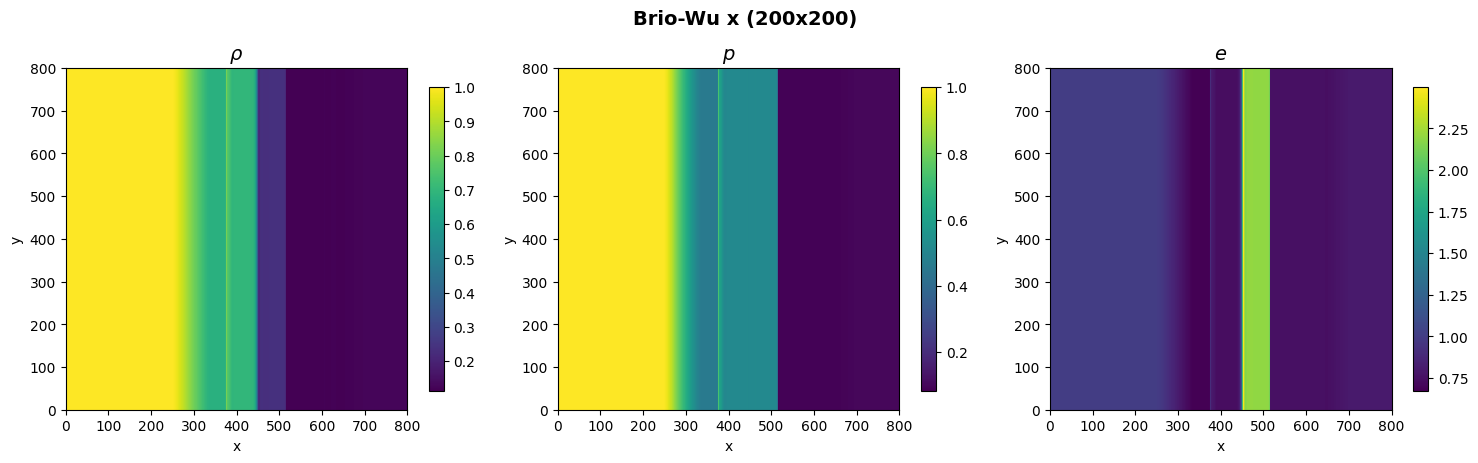

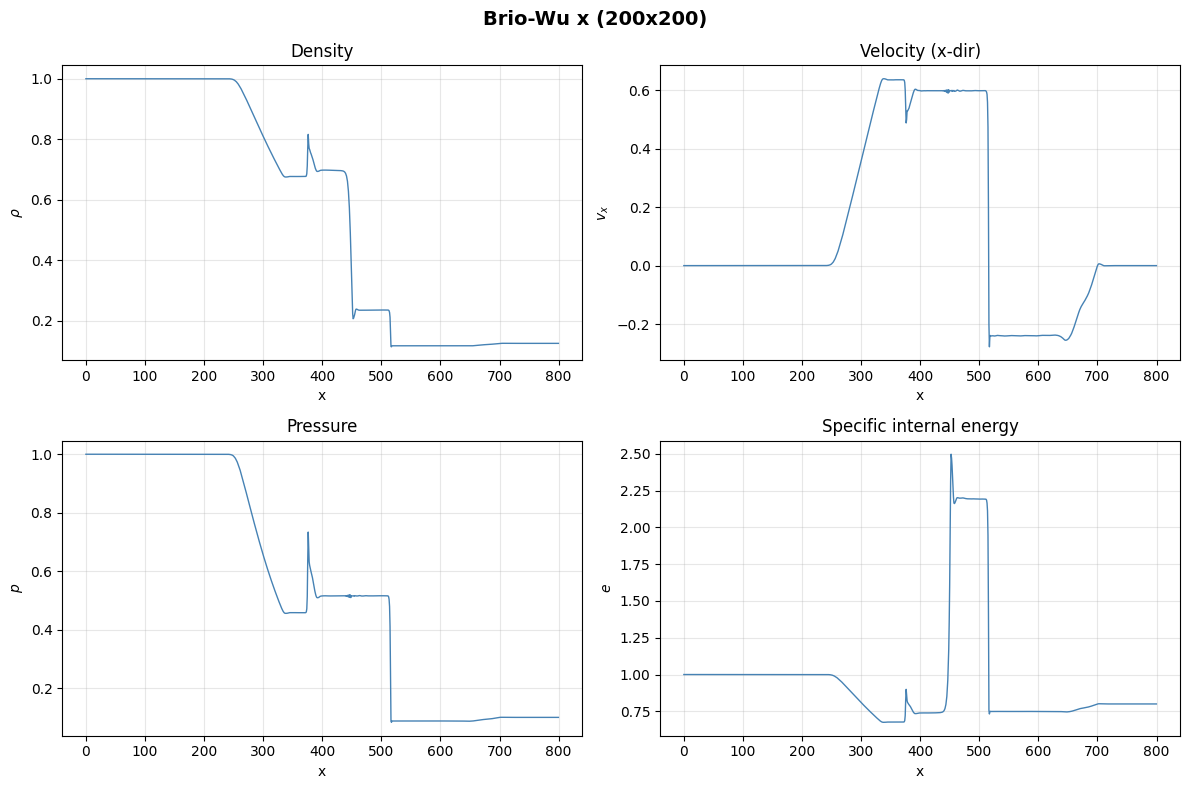

In [16]:
d = load_2d("test1_1000x4_hlld_glm.dat")
plot_2d_colormaps(d, "Brio-Wu x (200x200)")
plot_brio_wu(d, title="Brio-Wu x (200x200)")

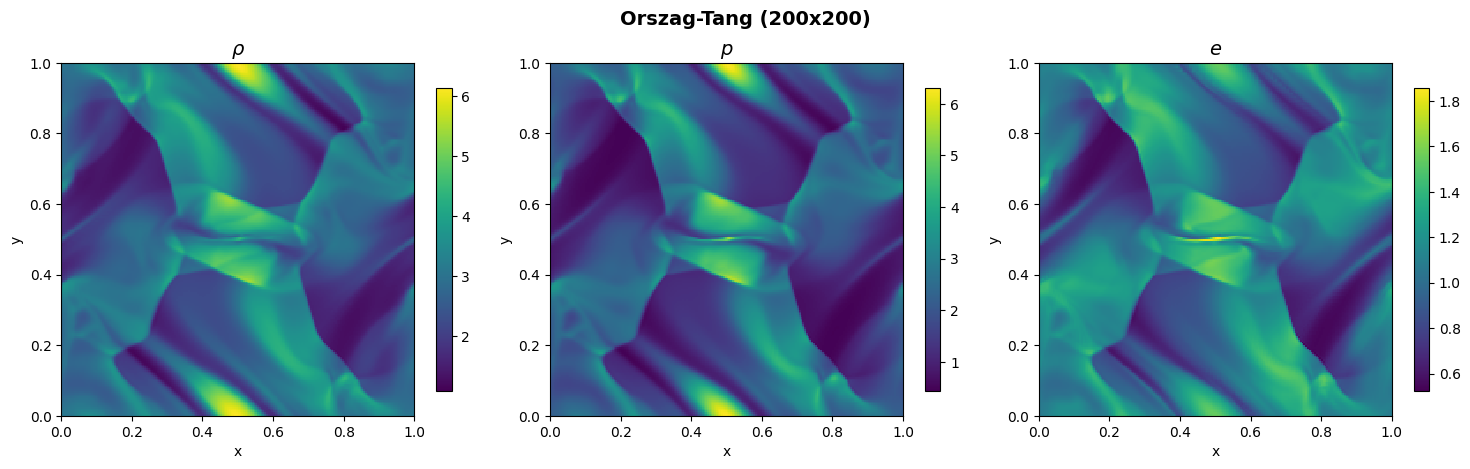

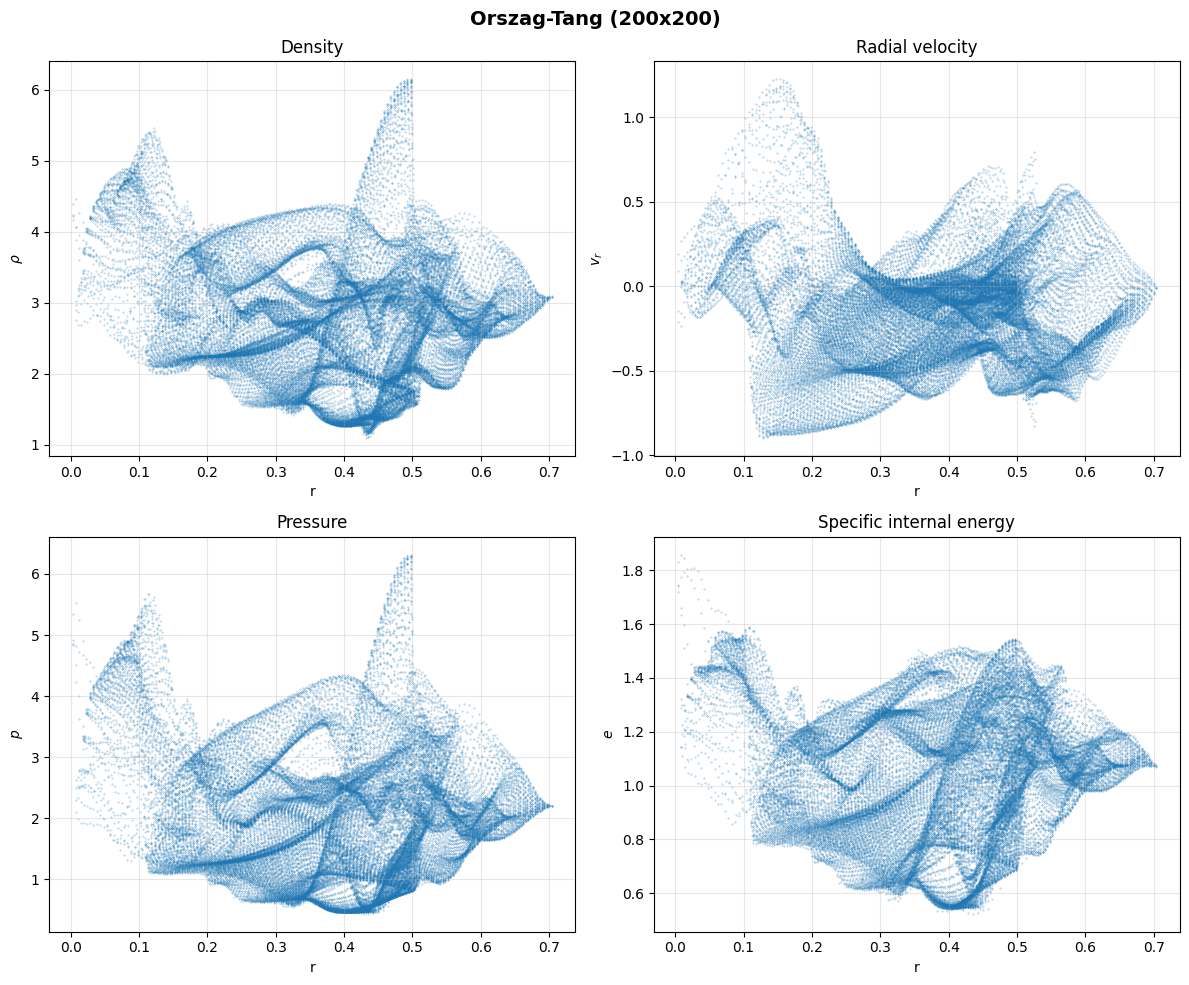

In [5]:
d = load_2d("test3_200x200_hlld_glm.dat")
plot_2d_colormaps(d, "Orszag-Tang (200x200)")
plot_radial_scatter(d, title="Orszag-Tang (200x200)")

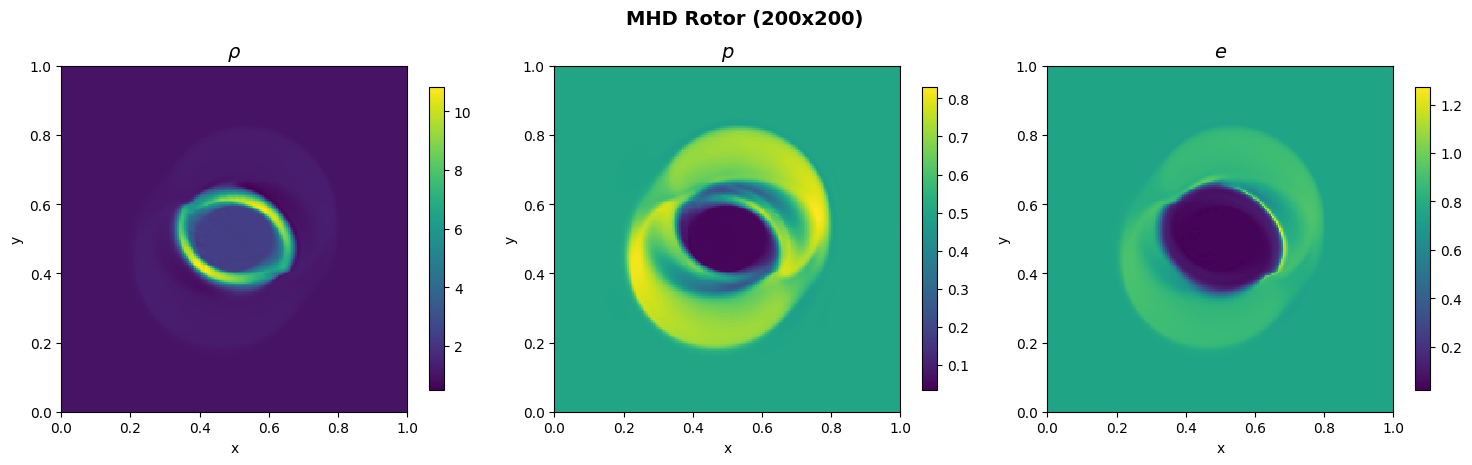

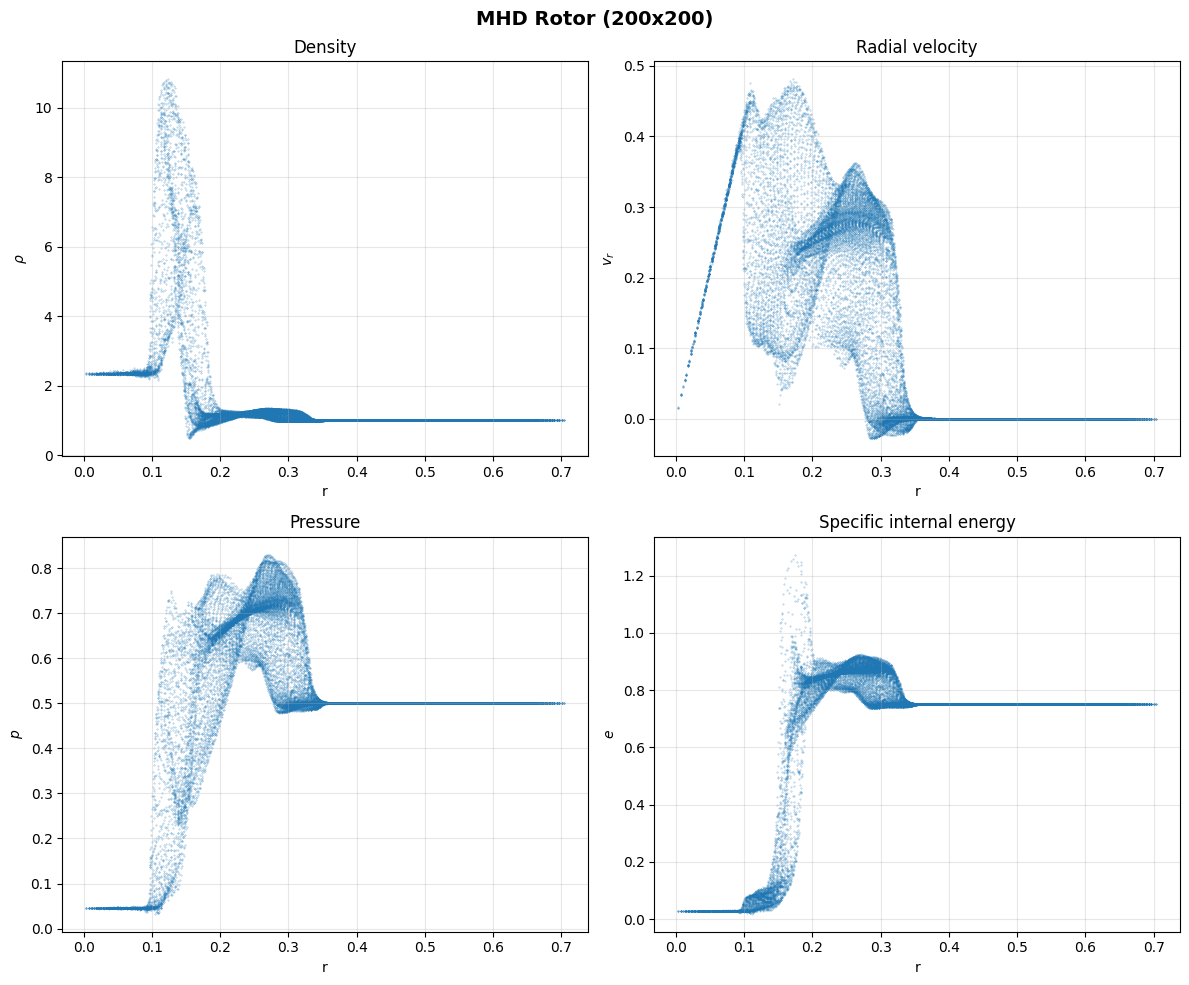

In [31]:
d = load_2d("test4_200x200_hlld_glm.dat")
plot_2d_colormaps(d, "MHD Rotor (200x200)")
plot_radial_scatter(d, title="MHD Rotor (200x200)")

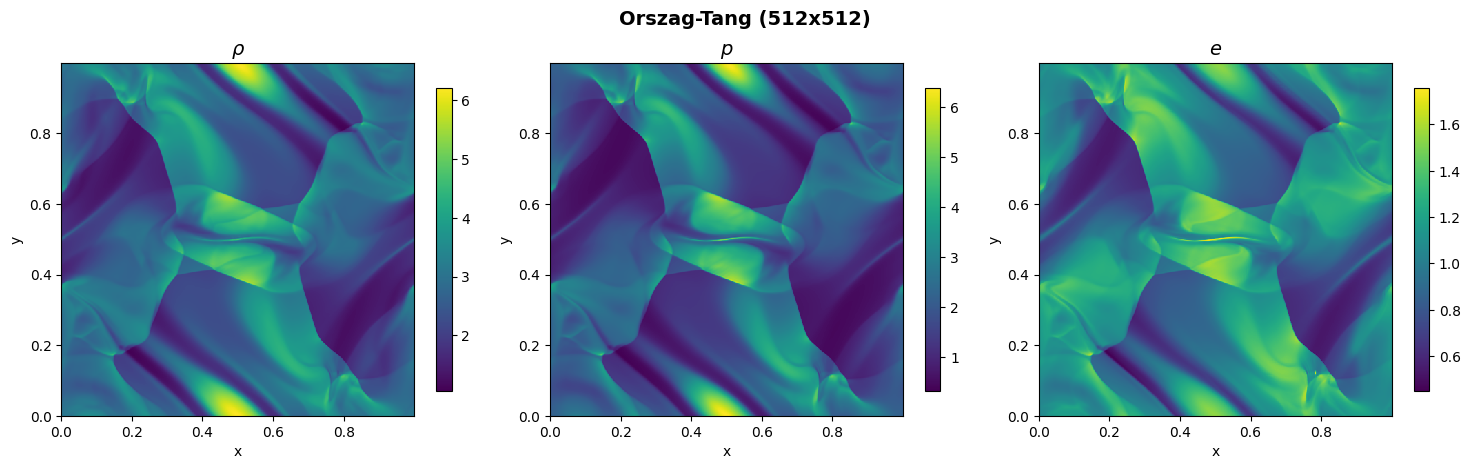

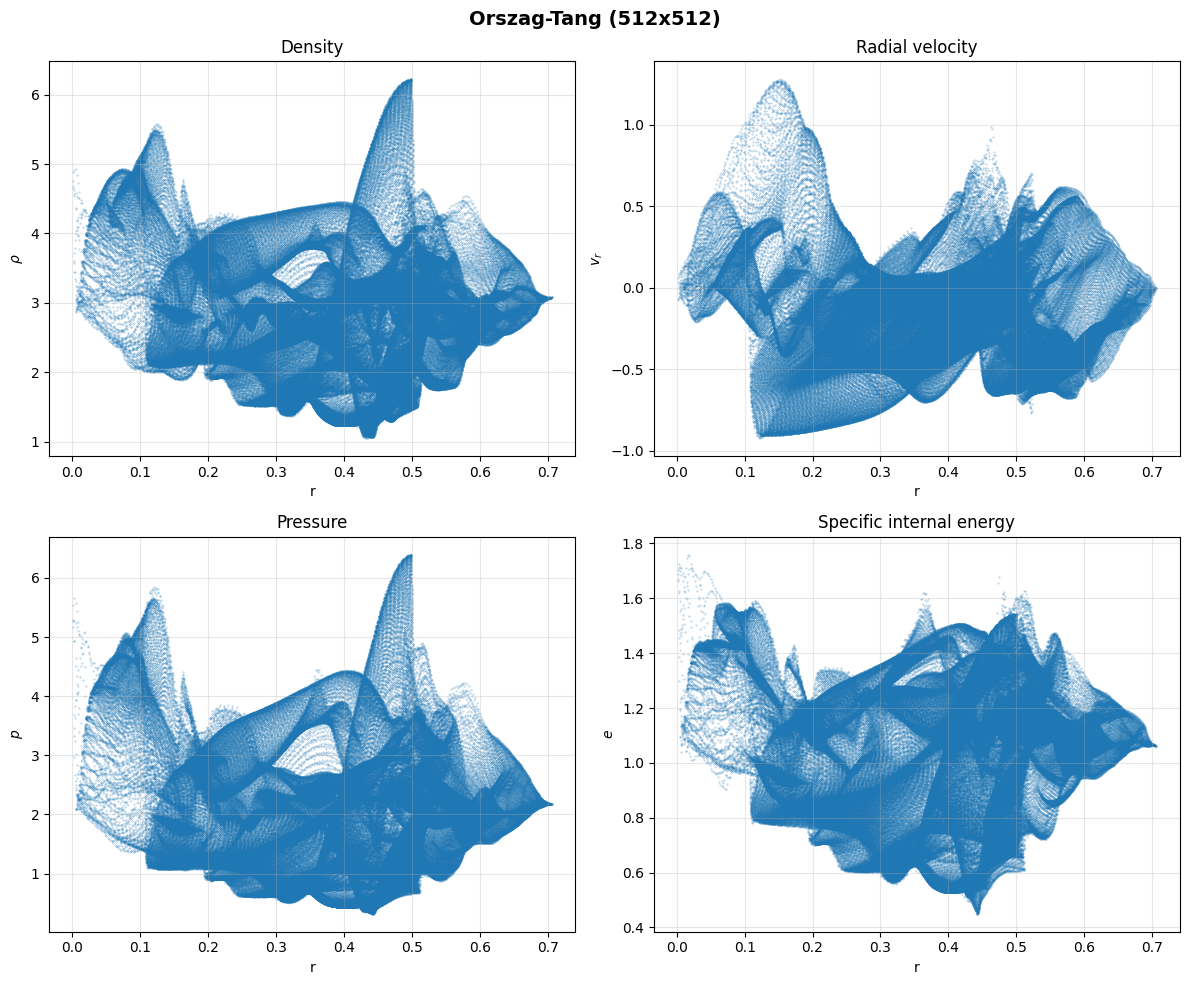

In [29]:
d = load_2d("test3_512x512_hlld_glm.dat")
plot_2d_colormaps(d, "Orszag-Tang (512x512)")
plot_radial_scatter(d, title="Orszag-Tang (512x512)")